In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["image.cmap"] = "gray"

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "echo2022"

TRAIN_CSV_PATH = DATA_ROOT / "train_data.csv"
SAMPLE_SUB_PATH = DATA_ROOT / "sample_submission.csv"

TRAIN_2CH_DIR = DATA_ROOT / "train_data" / "2CH"
TRAIN_4CH_DIR = DATA_ROOT / "train_data" / "4CH"
TEST_2CH_DIR = DATA_ROOT / "test_data" / "2CH"
TEST_4CH_DIR = DATA_ROOT / "test_data" / "4CH"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_CSV_PATH exists:", TRAIN_CSV_PATH.exists())
print("TRAIN_2CH_DIR exists:", TRAIN_2CH_DIR.exists())
print("TRAIN_4CH_DIR exists:", TRAIN_4CH_DIR.exists())
print("TEST_2CH_DIR exists:", TEST_2CH_DIR.exists())
print("TEST_4CH_DIR exists:", TEST_4CH_DIR.exists())

PROJECT_ROOT: /Users/emirarslan/Downloads/lab task/echo-project
DATA_ROOT: /Users/emirarslan/Downloads/lab task/echo-project/data/raw/echo2022
TRAIN_CSV_PATH exists: True
TRAIN_2CH_DIR exists: True
TRAIN_4CH_DIR exists: True
TEST_2CH_DIR exists: True
TEST_4CH_DIR exists: True


In [11]:
train_df = pd.read_csv(TRAIN_CSV_PATH)
sample_sub_df = pd.read_csv(SAMPLE_SUB_PATH)

print("train_df shape:", train_df.shape)
print("sample_sub_df shape:", sample_sub_df.shape)

display(train_df.head())
display(sample_sub_df.head())

train_df shape: (400, 2)
sample_sub_df shape: (50, 2)


,Patient_number,LV_ef
0,patient001,58.9
1,patient002,37.3
2,patient003,65.3
3,patient004,38.4
4,patient005,58.5


,Patient_number,LV_ef
0,patient0001,3.265477
1,patient0002,78.472759
2,patient0003,43.047281
3,patient0004,1.598960
4,patient0005,96.447658


In [12]:
sequence_number = []
train_img_w = []
train_img_h = []

for path in tqdm(sorted(TRAIN_2CH_DIR.glob("*.npy"))):
    number, height, width = np.load(path, mmap_mode="r").shape
    sequence_number.append(number)
    train_img_w.append(width)
    train_img_h.append(height)

print("Number of samples:", len(sequence_number))
print("Frame count min/max:", min(sequence_number), max(sequence_number))
print("Height min/max:", min(train_img_h), max(train_img_h))
print("Width min/max:", min(train_img_w), max(train_img_w))

100%|██████████| 400/400 [00:00<00:00, 3039.68it/s]

Number of samples: 400
Frame count min/max: 10 30
Height min/max: 584 1427
Width min/max: 323 898


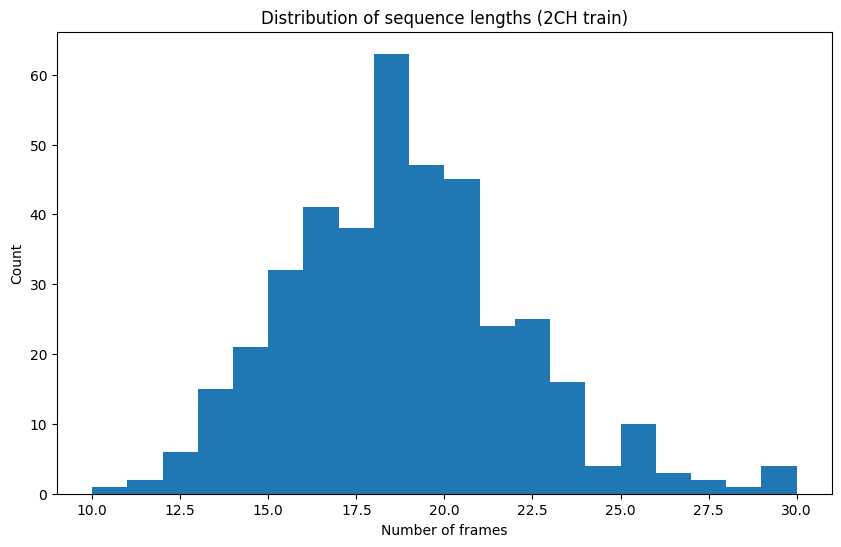

In [13]:
plt.hist(sequence_number, bins=20)
plt.title("Distribution of sequence lengths (2CH train)")
plt.xlabel("Number of frames")
plt.ylabel("Count")
plt.show()

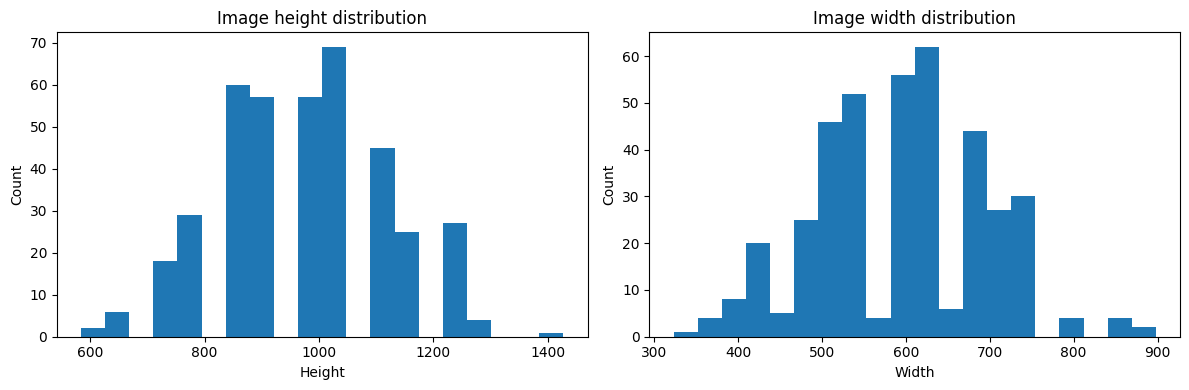

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_img_h, bins=20)
axes[0].set_title("Image height distribution")
axes[0].set_xlabel("Height")
axes[0].set_ylabel("Count")

axes[1].hist(train_img_w, bins=20)
axes[1].set_title("Image width distribution")
axes[1].set_xlabel("Width")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [15]:
sample_path = sorted(TRAIN_2CH_DIR.glob("*.npy"))[0]
sample_array = np.load(sample_path)

print("Sample file:", sample_path.name)
print("Shape:", sample_array.shape)
print("Dtype:", sample_array.dtype)
print("Min value:", sample_array.min())
print("Max value:", sample_array.max())

Sample file: patient001_2CH_sequence.npy
Shape: (20, 714, 433)
Dtype: float32
Min value: 0.0
Max value: 255.0


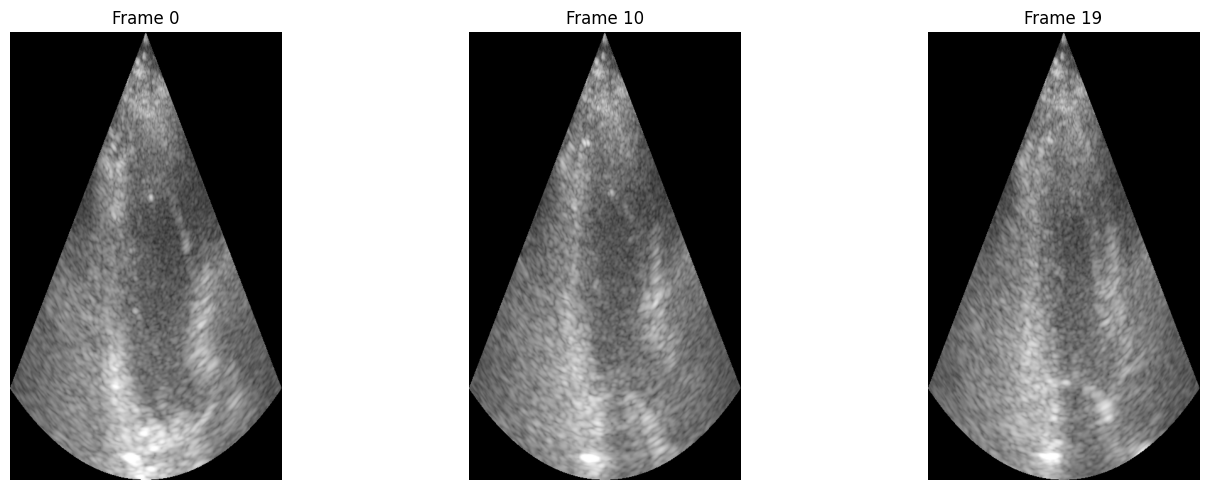

In [16]:
num_frames = sample_array.shape[0]
indices = [0, num_frames // 2, num_frames - 1]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, idx in zip(axes, indices):
    ax.imshow(sample_array[idx], cmap="gray")
    ax.set_title(f"Frame {idx}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [17]:
print(train_df.columns)

Index(['Patient_number', 'LV_ef'], dtype='str')


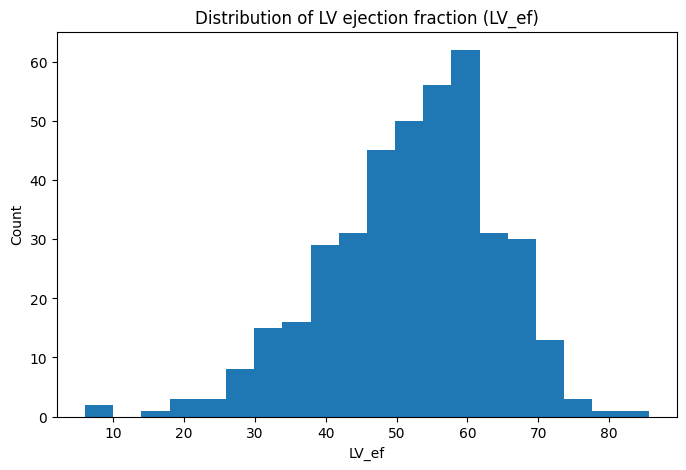

count    400.000000
mean      52.139500
std       11.983503
min        6.000000
25%       44.775000
50%       53.450000
75%       60.525000
max       85.600000
Name: LV_ef, dtype: float64


In [18]:
plt.figure(figsize=(8, 5))
plt.hist(train_df["LV_ef"], bins=20)
plt.title("Distribution of LV ejection fraction (LV_ef)")
plt.xlabel("LV_ef")
plt.ylabel("Count")
plt.show()

print(train_df["LV_ef"].describe())

In [19]:
sequence_number_4ch = []
train_img_w_4ch = []
train_img_h_4ch = []

for path in tqdm(sorted(TRAIN_4CH_DIR.glob("*.npy"))):
    number, height, width = np.load(path, mmap_mode="r").shape
    sequence_number_4ch.append(number)
    train_img_w_4ch.append(width)
    train_img_h_4ch.append(height)

print("Number of 4CH samples:", len(sequence_number_4ch))
print("4CH Frame count min/max:", min(sequence_number_4ch), max(sequence_number_4ch))
print("4CH Height min/max:", min(train_img_h_4ch), max(train_img_h_4ch))
print("4CH Width min/max:", min(train_img_w_4ch), max(train_img_w_4ch))

100%|██████████| 400/400 [00:00<00:00, 2730.56it/s]

Number of 4CH samples: 400
4CH Frame count min/max: 10 42
4CH Height min/max: 584 1427
4CH Width min/max: 323 915


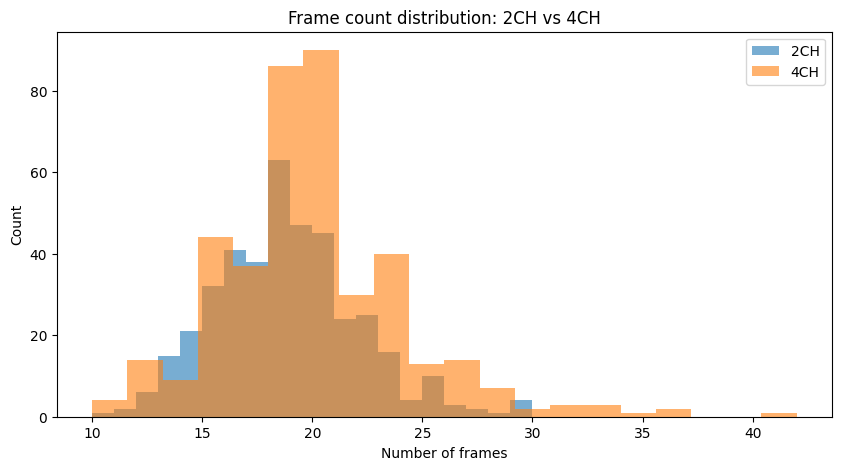

In [20]:
plt.figure(figsize=(10, 5))
plt.hist(sequence_number, bins=20, alpha=0.6, label="2CH")
plt.hist(sequence_number_4ch, bins=20, alpha=0.6, label="4CH")
plt.title("Frame count distribution: 2CH vs 4CH")
plt.xlabel("Number of frames")
plt.ylabel("Count")
plt.legend()
plt.show()

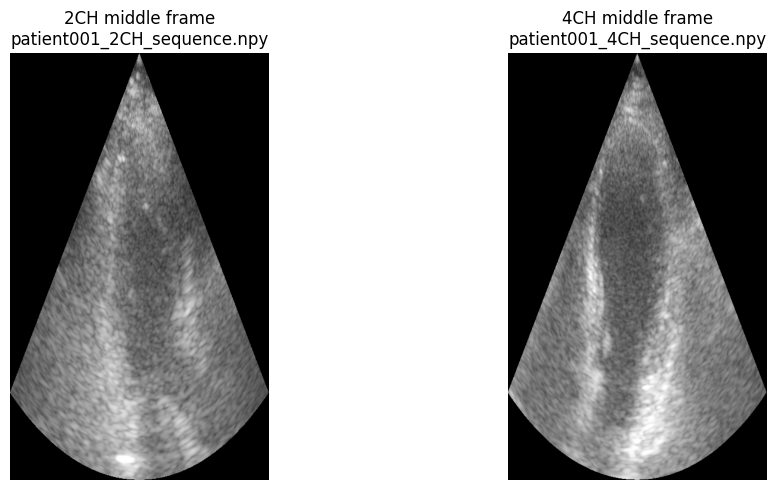

In [27]:
sample_2ch_path = sorted(TRAIN_2CH_DIR.glob("*.npy"))[0]
sample_4ch_path = sorted(TRAIN_4CH_DIR.glob("*.npy"))[0]

sample_2ch = np.load(sample_2ch_path)
sample_4ch = np.load(sample_4ch_path)

mid_2ch = sample_2ch.shape[0] // 2
mid_4ch = sample_4ch.shape[0] // 2

fig, axes = plt.subplots(1,2, figsize=(12,5))
axes[0].imshow(sample_2ch[mid_2ch], cmap="gray")
axes[0].set_title(f"2CH middle frame\n{sample_2ch_path.name}")
axes[0].axis("off")

axes[1].imshow(sample_4ch[mid_4ch], cmap="gray")
axes[1].set_title(f"4CH middle frame\n{sample_4ch_path.name}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [22]:
display(train_df.head(10))

,Patient_number,LV_ef
0,patient001,58.9
1,patient002,37.3
2,patient003,65.3
3,patient004,38.4
4,patient005,58.5
5,patient006,55.3
6,patient007,47.8
7,patient008,47.5
8,patient009,35.5
9,patient010,46.8


In [26]:
first_2ch_file = sorted(TRAIN_2CH_DIR.glob("*.npy"))[0]
first_4ch_file = sorted(TRAIN_4CH_DIR.glob("*.npy"))[0]

print("First 2CH file:", first_2ch_file.name)
print("First 4CH file:", first_4ch_file.name)

First 2CH file: patient001_2CH_sequence.npy
First 4CH file: patient001_4CH_sequence.npy


In [24]:
example_patient_id = first_2ch_file.stem.split("_")[0]
print("Extracted patient id:", example_patient_id)

Extracted patient id: patient001


In [25]:
train_df[train_df["Patient_number"] == example_patient_id]

,Patient_number,LV_ef
0,patient001,58.9


## Key observations from data exploration

- Each sample is a sequence of echocardiography frames stored as a `.npy` file.
- Both 2CH and 4CH views are available for the training data.
- The prediction target in the provided challenge is `LV_ef`.
- Sequence lengths are not necessarily identical across all patients, so frame selection or temporal standardization may be needed.
- Image sizes may vary, so resizing is required before model training.
- The Kaggle task is formulated as EF estimation from echo sequences, not direct segmentation.